# Social Media Emotion Analyzer
## SAIA 2163 — NLP Final Project
### Team: Syiqin, Ain, Saf

| Item | Details |
|------|---------|
| **Dataset** | DAIR-AI Emotion (Twitter, 20,000 samples) |
| **Task** | Multi-class emotion classification (6 emotions) |
| **Models** | Naive Bayes · Logistic Regression · LinearSVC · Word2Vec+LR · DistilBERT |
| **Platform** | Auto-detects CUDA / Apple MPS / CPU |

---


## Section 1: Setup

In [31]:
# Install all required packages
# Run this cell once; safe to skip on re-runs
!pip install datasets transformers[torch] evaluate scikit-learn gensim nltk wordcloud seaborn matplotlib pandas numpy joblib --quiet

zsh:1: no matches found: transformers[torch]


In [32]:
import pandas as pd
import numpy as np
import re
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)

# Word2Vec
from gensim.models import Word2Vec

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
sns.set_theme(style='whitegrid')

# HuggingFace / PyTorch
import torch
from datasets import load_dataset
from datasets import Dataset as HFDataset
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer, TrainingArguments
)
import evaluate as hf_evaluate

# ── Device auto-detection: CUDA > Apple MPS > CPU ──
if torch.cuda.is_available():
    DEVICE = 'cuda'
    print(f'Using CUDA GPU: {torch.cuda.get_device_name(0)}')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = 'mps'
    print('Using Apple Silicon MPS')
    # Enable fallback for MPS ops not yet supported
    os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
else:
    DEVICE = 'cpu'
    print('WARNING: Using CPU — DistilBERT training will be very slow!')

print(f'Device: {DEVICE}')

# Create output directories
os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('visualizations', exist_ok=True)
print('Directories ready.')

Using Apple Silicon MPS
Device: mps
Directories ready.


## Section 2: Data Loading & Exploration

**Dataset: DAIR-AI Emotion** (Google/HuggingFace)
- 20,000 English Twitter messages
- 6 emotion classes: joy, sadness, anger, fear, love, surprise
- Pre-split into train (16k) / validation (2k) / test (2k)
- More balanced than GoEmotions → enables higher model accuracy


In [33]:
# Load from HuggingFace (downloads automatically, ~2 MB)
print('Loading DAIR-AI Emotion dataset...')
raw_ds = load_dataset('dair-ai/emotion', 'split')

# Combine all splits into one DataFrame for EDA and classical models
train_df = pd.DataFrame(raw_ds['train'])
val_df   = pd.DataFrame(raw_ds['validation'])
test_df  = pd.DataFrame(raw_ds['test'])
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f'Total samples: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head()

Loading DAIR-AI Emotion dataset...
Total samples: 20000
Columns: ['text', 'label']


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [34]:
# Label mapping
id2label = {0: 'sadness', 1: 'joy', 2: 'love',
            3: 'anger',   4: 'fear', 5: 'surprise'}
label2id = {v: k for k, v in id2label.items()}

df['emotion'] = df['label'].map(id2label)

print('Class distribution:')
counts = df['emotion'].value_counts()
print(counts)
ratio = counts.max() / counts.min()
print(f'\nImbalance ratio (max/min): {ratio:.1f}x')
print('(Much more balanced than GoEmotions 14x imbalance)')

Class distribution:
emotion
joy         6761
sadness     5797
anger       2709
fear        2373
love        1641
surprise     719
Name: count, dtype: int64

Imbalance ratio (max/min): 9.4x
(Much more balanced than GoEmotions 14x imbalance)


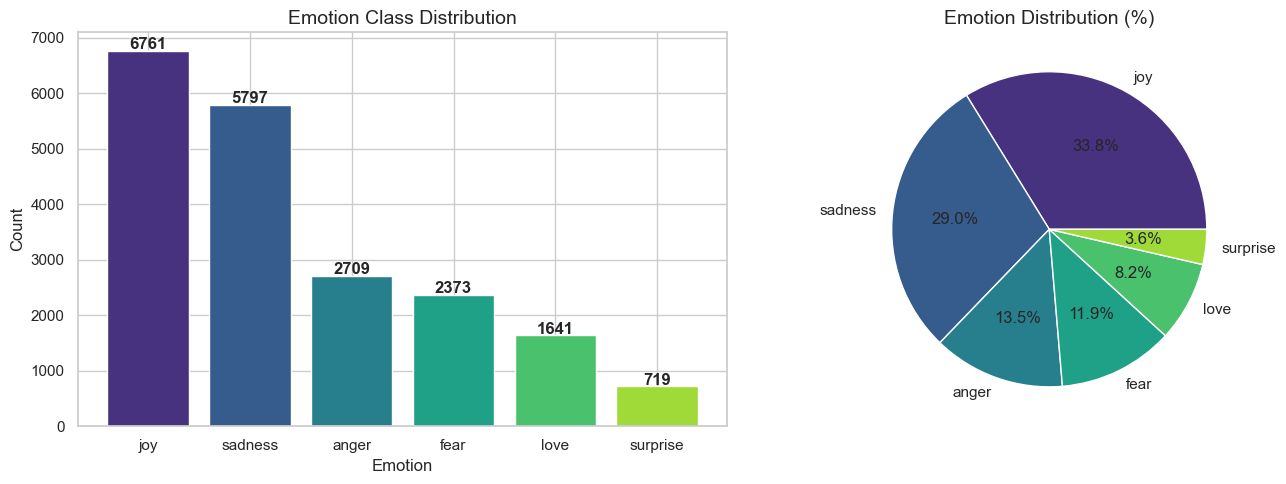

Saved: visualizations/class_distribution.png


In [35]:
# Chart 1: Class distribution (bar + pie)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
emotion_counts = df['emotion'].value_counts()
palette = sns.color_palette('viridis', len(emotion_counts))

# Bar chart
bars = axes[0].bar(emotion_counts.index, emotion_counts.values, color=palette)
axes[0].set_title('Emotion Class Distribution', fontsize=14)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, emotion_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 30,
                 str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(emotion_counts.values, labels=emotion_counts.index,
            autopct='%1.1f%%', colors=palette)
axes[1].set_title('Emotion Distribution (%)', fontsize=14)

plt.tight_layout()
plt.savefig('visualizations/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visualizations/class_distribution.png')

Word count statistics:
           count  mean   std  min   25%   50%   75%   max
emotion                                                  
anger     2709.0  19.2  11.3  2.0  10.0  17.0  26.0  62.0
fear      2373.0  18.7  10.9  2.0  10.0  16.0  25.0  60.0
joy       6761.0  19.4  10.8  2.0  11.0  17.0  26.0  64.0
love      1641.0  20.6  10.7  3.0  12.0  19.0  27.0  63.0
sadness   5797.0  18.4  11.0  2.0  10.0  16.0  24.0  66.0
surprise   719.0  19.7  11.0  3.0  11.0  17.0  26.0  61.0


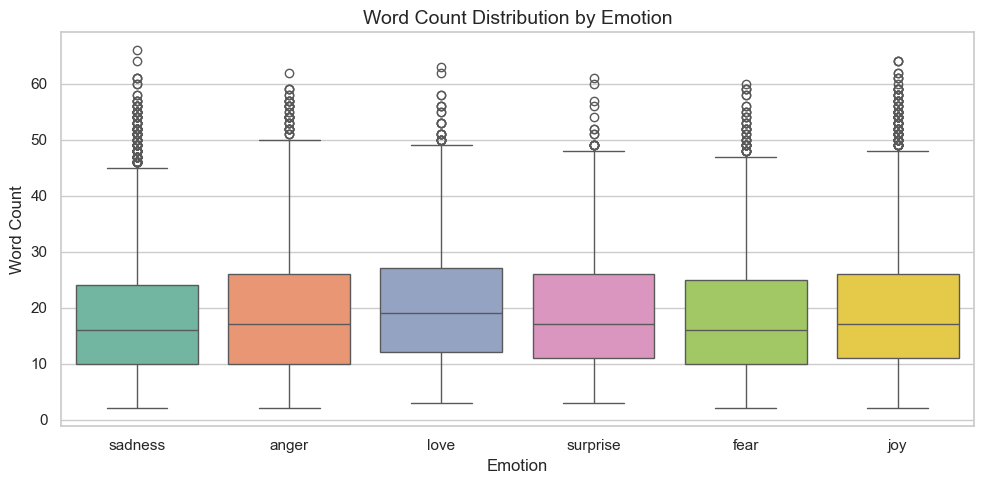

In [36]:
# Chart 2: Text length distribution by emotion
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

print('Word count statistics:')
print(df.groupby('emotion')['word_count'].describe().round(1))

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='emotion', y='word_count', palette='Set2')
plt.title('Word Count Distribution by Emotion', fontsize=14)
plt.xlabel('Emotion')
plt.ylabel('Word Count')
plt.tight_layout()
plt.savefig('visualizations/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3: Text Preprocessing

**Pipeline (applied in order):**
1. Lowercase
2. Remove URLs (`http://...`, `https://...`)
3. Remove @mentions
4. Remove hashtag `#` symbol (keep word)
5. Remove non-alphabetic characters
6. Tokenize (split into words)
7. Remove English stopwords
8. Lemmatize (WordNet)


In [37]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()                           # 1. lowercase
    text = re.sub(r'http\S+', '', text)               # 2. remove URLs
    text = re.sub(r'@\w+', '', text)                  # 3. remove @mentions
    text = re.sub(r'#', '', text)                     # 4. remove # symbol
    text = re.sub(r'[^a-zA-Z\s]', '', text)           # 5. letters only
    words = text.split()                              # 6. tokenize
    words = [lemmatizer.lemmatize(w)                  # 8. lemmatize
             for w in words                           # 7. remove stopwords
             if w not in stop_words and len(w) > 1]
    return ' '.join(words)

# Show before vs after
print('--- Before preprocessing ---')
print(repr(df['text'][5]))
print('\n--- After preprocessing ---')
print(repr(preprocess(df['text'][5])))

--- Before preprocessing ---
'ive been feeling a little burdened lately wasnt sure why that was'

--- After preprocessing ---
'ive feeling little burdened lately wasnt sure'


In [38]:
# Apply preprocessing to all text
print('Preprocessing... (may take ~30 seconds)')
df['clean_text'] = df['text'].apply(preprocess)
print('Done!')

# Show 10 examples
df[['text', 'emotion', 'clean_text']].head(10)

Preprocessing... (may take ~30 seconds)
Done!


,text,emotion,clean_text
0,i didnt feel humiliated,sadness,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,sadness,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,anger,im grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,love,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,anger,feeling grouchy
5,ive been feeling a little burdened lately wasn...,sadness,ive feeling little burdened lately wasnt sure
6,ive been taking or milligrams or times recomme...,surprise,ive taking milligram time recommended amount i...
7,i feel as confused about life as a teenager or...,fear,feel confused life teenager jaded year old man
8,i have been with petronas for years i feel tha...,joy,petronas year feel petronas performed well mad...
9,i feel romantic too,love,feel romantic


In [39]:
# Save processed dataset
df.to_csv('data/emotion_dataset_processed.csv', index=False)
print(f'Saved {len(df)} processed samples to data/emotion_dataset_processed.csv')

Saved 20000 processed samples to data/emotion_dataset_processed.csv


## Section 4: Train / Test Split

**Key principle:** Split the data FIRST, then fit vectorizers ONLY on training data.
This prevents **data leakage** — the test set must never influence the vectorizer.

Split ratio: **80% train / 20% test** (stratified to preserve class balance)


In [40]:
X = df['clean_text']
y = df['emotion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,       # ensures same class proportions in both splits
    random_state=42
)

print(f'Training samples:  {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test samples:      {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)')
print(f'\nClass distribution in training set:')
print(y_train.value_counts())

Training samples:  16000 (80%)
Test samples:      4000 (20%)

Class distribution in training set:
emotion
joy         5409
sadness     4638
anger       2167
fear        1898
love        1313
surprise     575
Name: count, dtype: int64


## Section 5: Feature Extraction

We implement **two** feature extraction methods:

| Method | Description | Library |
|--------|-------------|---------|
| **TF-IDF** | Weighs words by frequency × inverse doc frequency; includes bigrams | scikit-learn |
| **Word2Vec** | Neural embeddings capturing semantic meaning; averaged per document | Gensim |

Both are fit **only on training data** — never on test data.


### 5.1 Feature Method 1 — TF-IDF (with Bigrams)

In [41]:
# Fit TF-IDF on TRAINING data only, then transform both splits
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),    # unigrams + bigrams (captures 'feel sad', 'so happy')
    sublinear_tf=True      # log(tf) — reduces effect of very frequent words
)

X_train_tfidf = tfidf.fit_transform(X_train)  # fit on train, then transform
X_test_tfidf  = tfidf.transform(X_test)         # transform only (no fitting)

print(f'TF-IDF train matrix: {X_train_tfidf.shape}')
print(f'TF-IDF test matrix:  {X_test_tfidf.shape}')

# Save vectorizer
joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')
print('Saved: models/tfidf_vectorizer.pkl')

TF-IDF train matrix: (16000, 10000)
TF-IDF test matrix:  (4000, 10000)
Saved: models/tfidf_vectorizer.pkl


Top 20 TF-IDF features:
      word      score
      feel 820.945546
   feeling 568.711010
      like 371.462519
        im 337.756062
 feel like 289.678967
im feeling 187.083161
    really 167.396476
      time 156.786035
      know 146.417983
    little 143.300107
      make 128.671574
       get 127.677136
      want 121.013027
     still 117.060212
    people 116.763171
       day 116.652687
     thing 112.838800
       one 112.515271
     would 112.266427
     think 110.587589


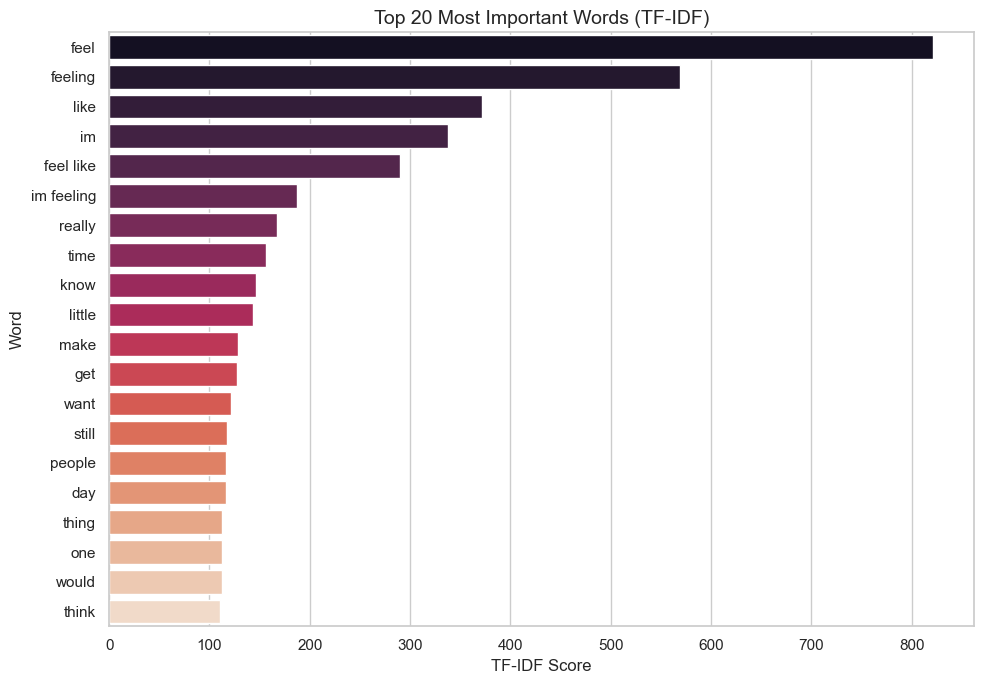

In [42]:
# Chart 3: Top 20 TF-IDF words
feature_names = tfidf.get_feature_names_out()
scores = np.asarray(X_train_tfidf.sum(axis=0)).ravel()
top_words_df = (pd.DataFrame({'word': feature_names, 'score': scores})
                .sort_values('score', ascending=False)
                .reset_index(drop=True))

print('Top 20 TF-IDF features:')
print(top_words_df.head(20).to_string(index=False))

plt.figure(figsize=(10, 7))
sns.barplot(x='score', y='word', data=top_words_df.head(20), palette='rocket')
plt.title('Top 20 Most Important Words (TF-IDF)', fontsize=14)
plt.xlabel('TF-IDF Score')
plt.ylabel('Word')
plt.tight_layout()
plt.savefig('visualizations/top20_tfidf_words.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Feature Method 2 — Word2Vec (Neural Embeddings)

In [43]:
# Train Word2Vec on TRAINING sentences only
train_sentences = [text.split() for text in X_train]

w2v_model = Word2Vec(
    train_sentences,
    vector_size=100,   # 100-dimensional word vectors
    window=5,          # context window
    min_count=2,       # ignore words appearing < 2 times
    workers=4,
    epochs=30,
    seed=42
)

print(f'Word2Vec vocabulary size: {len(w2v_model.wv)}')
print()

for word in ['happy', 'sad', 'angry', 'fear']:
    try:
        similar = w2v_model.wv.most_similar(word, topn=3)
        print(f"'{word}' is similar to: {[w for w, s in similar]}")
    except KeyError:
        print(f"'{word}' not in vocabulary")

w2v_model.save('models/word2vec.model')
print('\nSaved: models/word2vec.model')

Word2Vec vocabulary size: 6651

'happy' is similar to: ['relieved', 'thankful', 'paragraph']
'sad' is similar to: ['upset', 'angry', 'lonely']
'angry' is similar to: ['sad', 'frustrated', 'upset']
'fear' is similar to: ['deeply', 'hurtful', 'unkind']

Saved: models/word2vec.model


In [44]:
# Build document vectors by averaging word vectors
def text_to_w2v(text, model, size=100):
    words = text.split()
    vecs = [model.wv[w] for w in words if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

print('Building Word2Vec document vectors...')
X_train_w2v = np.array([text_to_w2v(t, w2v_model) for t in X_train])
X_test_w2v  = np.array([text_to_w2v(t, w2v_model) for t in X_test])

print(f'Word2Vec train matrix: {X_train_w2v.shape}')
print(f'Word2Vec test matrix:  {X_test_w2v.shape}')

Building Word2Vec document vectors...
Word2Vec train matrix: (16000, 100)
Word2Vec test matrix:  (4000, 100)


## Section 6: Classical Model Training

**4 models trained and compared:**
1. Naive Bayes (TF-IDF) — fast baseline
2. Logistic Regression (TF-IDF) — strong classical model
3. LinearSVC / SVM (TF-IDF) — typically best classical for text
4. Logistic Regression (Word2Vec) — demonstrates 2nd feature method

**`class_weight='balanced'`** — automatically handles class imbalance by weighting minority classes higher.

**Metrics reported:** Accuracy + Macro-F1 (macro-F1 is fairer for imbalanced classes)


In [46]:
# Shared storage and evaluation function
results = {}

def evaluate_model(name, y_true, y_pred):
    acc      = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    results[name] = {'accuracy': acc, 'macro_f1': macro_f1}
    print("\n" + "=" * 58)
    print(f'  {name}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Macro-F1 : {macro_f1:.4f}')
    print("=" * 58)
    print(classification_report(y_true, y_pred))
    return acc, macro_f1

In [47]:
# ── Model 1: Naive Bayes (TF-IDF) ──
print('Training Naive Bayes...')
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)
evaluate_model('Naive Bayes (TF-IDF)', y_test, nb_preds)

Training Naive Bayes...

  Naive Bayes (TF-IDF)
  Accuracy : 0.7578
  Macro-F1 : 0.5754
              precision    recall  f1-score   support

       anger       0.96      0.54      0.69       542
        fear       0.91      0.50      0.65       475
         joy       0.70      0.98      0.82      1352
        love       1.00      0.18      0.30       328
     sadness       0.75      0.95      0.84      1159
    surprise       1.00      0.08      0.15       144

    accuracy                           0.76      4000
   macro avg       0.89      0.54      0.58      4000
weighted avg       0.81      0.76      0.72      4000



(0.75775, 0.5753871421031166)

In [48]:
# ── Model 2: Logistic Regression (TF-IDF) ──
print('Training Logistic Regression...')
lr_model = LogisticRegression(
    max_iter=2000, random_state=42, class_weight='balanced'
)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)
evaluate_model('Logistic Regression (TF-IDF)', y_test, lr_preds)

Training Logistic Regression...

  Logistic Regression (TF-IDF)
  Accuracy : 0.9000
  Macro-F1 : 0.8685
              precision    recall  f1-score   support

       anger       0.89      0.88      0.89       542
        fear       0.88      0.85      0.87       475
         joy       0.95      0.90      0.92      1352
        love       0.72      0.95      0.82       328
     sadness       0.96      0.92      0.94      1159
    surprise       0.68      0.90      0.77       144

    accuracy                           0.90      4000
   macro avg       0.85      0.90      0.87      4000
weighted avg       0.91      0.90      0.90      4000



(0.9, 0.8684668950538454)

In [49]:
# ── Model 3: LinearSVC / SVM (TF-IDF) ──
print('Training LinearSVC (SVM)...')
svm_model = LinearSVC(
    random_state=42, class_weight='balanced', max_iter=3000
)
svm_model.fit(X_train_tfidf, y_train)
svm_preds = svm_model.predict(X_test_tfidf)
evaluate_model('LinearSVC / SVM (TF-IDF)', y_test, svm_preds)

Training LinearSVC (SVM)...

  LinearSVC / SVM (TF-IDF)
  Accuracy : 0.9055
  Macro-F1 : 0.8704
              precision    recall  f1-score   support

       anger       0.90      0.90      0.90       542
        fear       0.88      0.88      0.88       475
         joy       0.94      0.91      0.93      1352
        love       0.76      0.88      0.81       328
     sadness       0.94      0.93      0.94      1159
    surprise       0.76      0.76      0.76       144

    accuracy                           0.91      4000
   macro avg       0.86      0.88      0.87      4000
weighted avg       0.91      0.91      0.91      4000



(0.9055, 0.870383092111799)

In [51]:
# ── Model 4: Logistic Regression (Word2Vec) ──
print('Training Logistic Regression on Word2Vec features...')
lr_w2v = LogisticRegression(
    max_iter=2000, random_state=42, class_weight='balanced'
)
lr_w2v.fit(X_train_w2v, y_train)
lr_w2v_preds = lr_w2v.predict(X_test_w2v)
evaluate_model('Logistic Regression (Word2Vec)', y_test, lr_w2v_preds)

Training Logistic Regression on Word2Vec features...

  Logistic Regression (Word2Vec)
  Accuracy : 0.4470
  Macro-F1 : 0.3940
              precision    recall  f1-score   support

       anger       0.35      0.41      0.38       542
        fear       0.33      0.35      0.34       475
         joy       0.69      0.51      0.59      1352
        love       0.28      0.48      0.35       328
     sadness       0.59      0.42      0.49      1159
    surprise       0.15      0.48      0.22       144

    accuracy                           0.45      4000
   macro avg       0.40      0.44      0.39      4000
weighted avg       0.52      0.45      0.47      4000



(0.447, 0.3940302241670084)

## Section 7: DistilBERT Fine-Tuning *(Bonus +5 marks)*

DistilBERT is a compact transformer model (66M parameters) that is 40% smaller and 60% faster
than BERT, while retaining ~97% of its language understanding.

**Expected training time:**
- NVIDIA GPU (e.g., RTX 5070 Ti): ~3–8 minutes
- Apple Silicon MPS (M-series): ~20–35 minutes
- CPU only: several hours *(not recommended)*

**Note:** We use **raw (unpreprocessed) text** for BERT — its own WordPiece tokenizer
handles punctuation, casing, and subwords better than our manual pipeline.


In [52]:
# Prepare raw text for BERT (same 80/20 stratified split, same seed)
X_raw = df['text'].tolist()
y_enc = df['label'].tolist()

X_train_raw, X_test_raw, y_train_enc, y_test_enc = train_test_split(
    X_raw, y_enc,
    test_size=0.2, stratify=y_enc, random_state=42
)

print(f'BERT train samples: {len(X_train_raw)}')
print(f'BERT test samples:  {len(X_test_raw)}')

BERT train samples: 16000
BERT test samples:  4000


In [53]:
# Tokenizer
BERT_MODEL = 'distilbert-base-uncased'
tokenizer  = DistilBertTokenizer.from_pretrained(BERT_MODEL)

# Create HuggingFace Dataset objects
hf_train = HFDataset.from_dict({'text': X_train_raw, 'label': y_train_enc})
hf_test  = HFDataset.from_dict({'text': X_test_raw,  'label': y_test_enc})

def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

tok_train = hf_train.map(tokenize_fn, batched=True)
tok_test  = hf_test.map(tokenize_fn,  batched=True)
print('Tokenization done!')

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Tokenization done!


In [54]:
# Load model
bert_model = DistilBertForSequenceClassification.from_pretrained(
    BERT_MODEL,
    num_labels=6,
    id2label=id2label,
    label2id=label2id
)

n_params = sum(p.numel() for p in bert_model.parameters()) / 1_000_000
print(f'DistilBERT loaded — {n_params:.0f}M parameters')

# Metrics
acc_metric = hf_evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = acc_metric.compute(predictions=preds, references=labels)['accuracy']
    mf1 = f1_score(labels, preds, average='macro')
    return {'accuracy': acc, 'macro_f1': mf1}

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT loaded — 67M parameters


In [55]:
# Training arguments — Trainer auto-detects CUDA / MPS / CPU
training_args = TrainingArguments(
    output_dir='./bert_checkpoints',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    logging_steps=50,
    report_to='none',          # disables wandb/tensorboard
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=tok_train,
    eval_dataset=tok_test,
    compute_metrics=compute_metrics,
)

print(f'Starting DistilBERT training on: {DEVICE.upper()}')
print('Expected time: 3-8 min (CUDA) | 20-35 min (MPS) | hours (CPU)')
print('-' * 50)
trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting DistilBERT training on: MPS
Expected time: 3-8 min (CUDA) | 20-35 min (MPS) | hours (CPU)
--------------------------------------------------


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.266852,0.194712,0.930750,0.901193
2,0.167721,0.150022,0.931750,0.898901
3,0.088969,0.143532,0.938500,0.905383
4,0.074155,0.141295,0.937000,0.911103


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2000, training_loss=0.29790478467941284, metrics={'train_runtime': 1339.3908, 'train_samples_per_second': 47.783, 'train_steps_per_second': 1.493, 'total_flos': 2119629570048000.0, 'train_loss': 0.29790478467941284, 'epoch': 4.0})

In [56]:
# Evaluate DistilBERT and record results
bert_out   = trainer.predict(tok_test)
bert_preds_enc = np.argmax(bert_out.predictions, axis=-1)

# Convert integer labels → emotion strings for consistent comparison
y_test_bert = [id2label[i] for i in y_test_enc]
bert_preds  = [id2label[i] for i in bert_preds_enc]

evaluate_model('DistilBERT (fine-tuned)', y_test_bert, bert_preds)

# Save model and tokenizer
bert_model.save_pretrained('models/best_transformer_model')
tokenizer.save_pretrained('models/best_transformer_model')
print('\nSaved: models/best_transformer_model/')


  DistilBERT (fine-tuned)
  Accuracy : 0.9370
  Macro-F1 : 0.9111
              precision    recall  f1-score   support

       anger       0.94      0.93      0.93       542
        fear       0.91      0.92      0.91       475
         joy       0.97      0.94      0.95      1352
        love       0.81      0.90      0.85       328
     sadness       0.97      0.96      0.97      1159
    surprise       0.83      0.86      0.85       144

    accuracy                           0.94      4000
   macro avg       0.90      0.92      0.91      4000
weighted avg       0.94      0.94      0.94      4000



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved: models/best_transformer_model/


## Section 8: Model Comparison

In [57]:
# Comparison table
comp = pd.DataFrame(results).T
comp.columns = ['Accuracy', 'Macro-F1']
comp = comp.sort_values('Accuracy', ascending=False)
comp_display = comp.copy()
comp_display['Accuracy'] = comp_display['Accuracy'].map('{:.4f}'.format)
comp_display['Macro-F1'] = comp_display['Macro-F1'].map('{:.4f}'.format)

print('=' * 58)
print('           FINAL MODEL COMPARISON')
print('=' * 58)
print(comp_display.to_string())
print('\nBest model:', comp.index[0])

           FINAL MODEL COMPARISON
                               Accuracy Macro-F1
DistilBERT (fine-tuned)          0.9370   0.9111
LinearSVC / SVM (TF-IDF)         0.9055   0.8704
Logistic Regression (TF-IDF)     0.9000   0.8685
Naive Bayes (TF-IDF)             0.7578   0.5754
Logistic Regression (Word2Vec)   0.4470   0.3940

Best model: DistilBERT (fine-tuned)


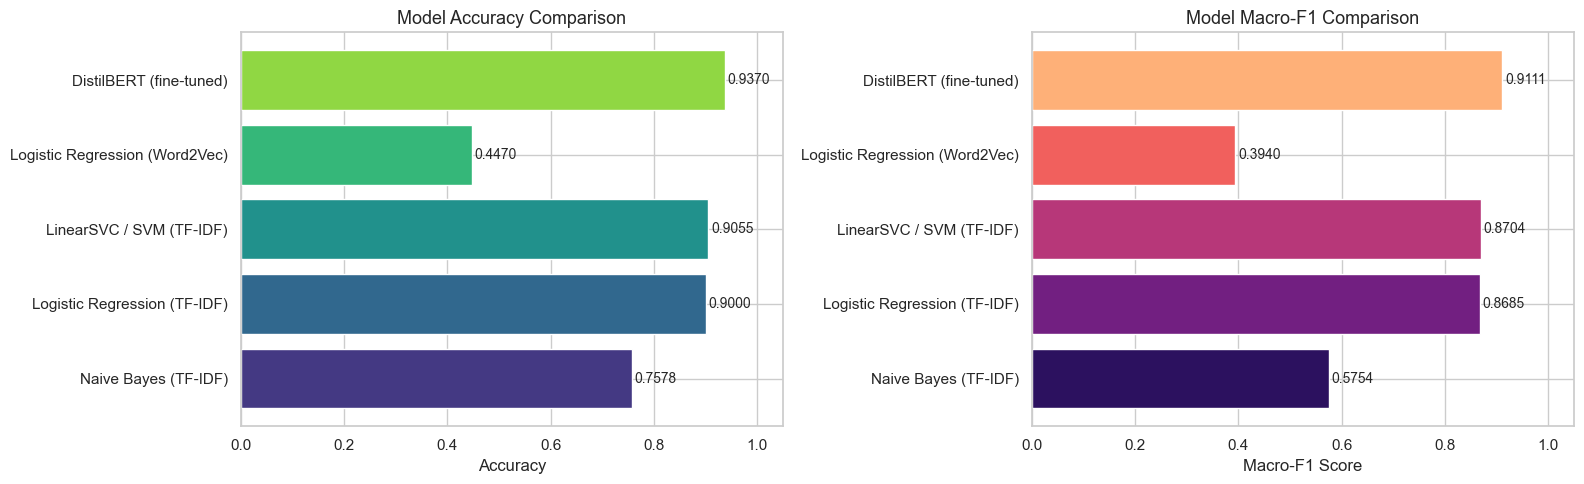

In [58]:
# Chart 4: Model comparison bar chart
model_names = list(results.keys())
accs = [results[m]['accuracy']  for m in model_names]
f1s  = [results[m]['macro_f1']  for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy
bars1 = axes[0].barh(model_names, accs,
                     color=sns.color_palette('viridis', len(model_names)))
axes[0].set_xlim(0, 1.05)
axes[0].set_title('Model Accuracy Comparison', fontsize=13)
axes[0].set_xlabel('Accuracy')
for bar, v in zip(bars1, accs):
    axes[0].text(v + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=10)

# Macro-F1
bars2 = axes[1].barh(model_names, f1s,
                     color=sns.color_palette('magma', len(model_names)))
axes[1].set_xlim(0, 1.05)
axes[1].set_title('Model Macro-F1 Comparison', fontsize=13)
axes[1].set_xlabel('Macro-F1 Score')
for bar, v in zip(bars2, f1s):
    axes[1].text(v + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('visualizations/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9: Visualizations

### 9.1 Word Cloud — All Emotions

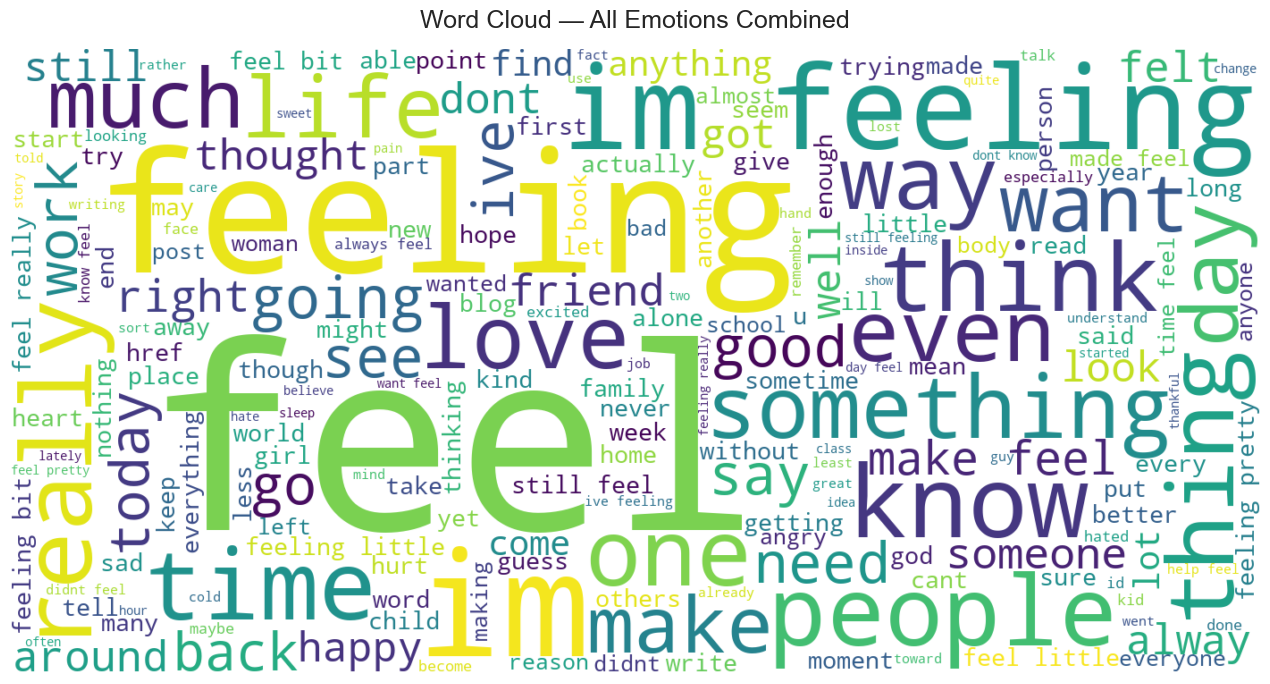

In [59]:
plt.figure(figsize=(14, 7))
all_text = ' '.join(df['clean_text'].fillna('').tolist())
wc = WordCloud(width=1400, height=700, background_color='white',
               colormap='viridis', max_words=200).generate(all_text)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — All Emotions Combined', fontsize=18, pad=15)
plt.tight_layout()
plt.savefig('visualizations/wordcloud_all.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.2 Per-Emotion Word Clouds

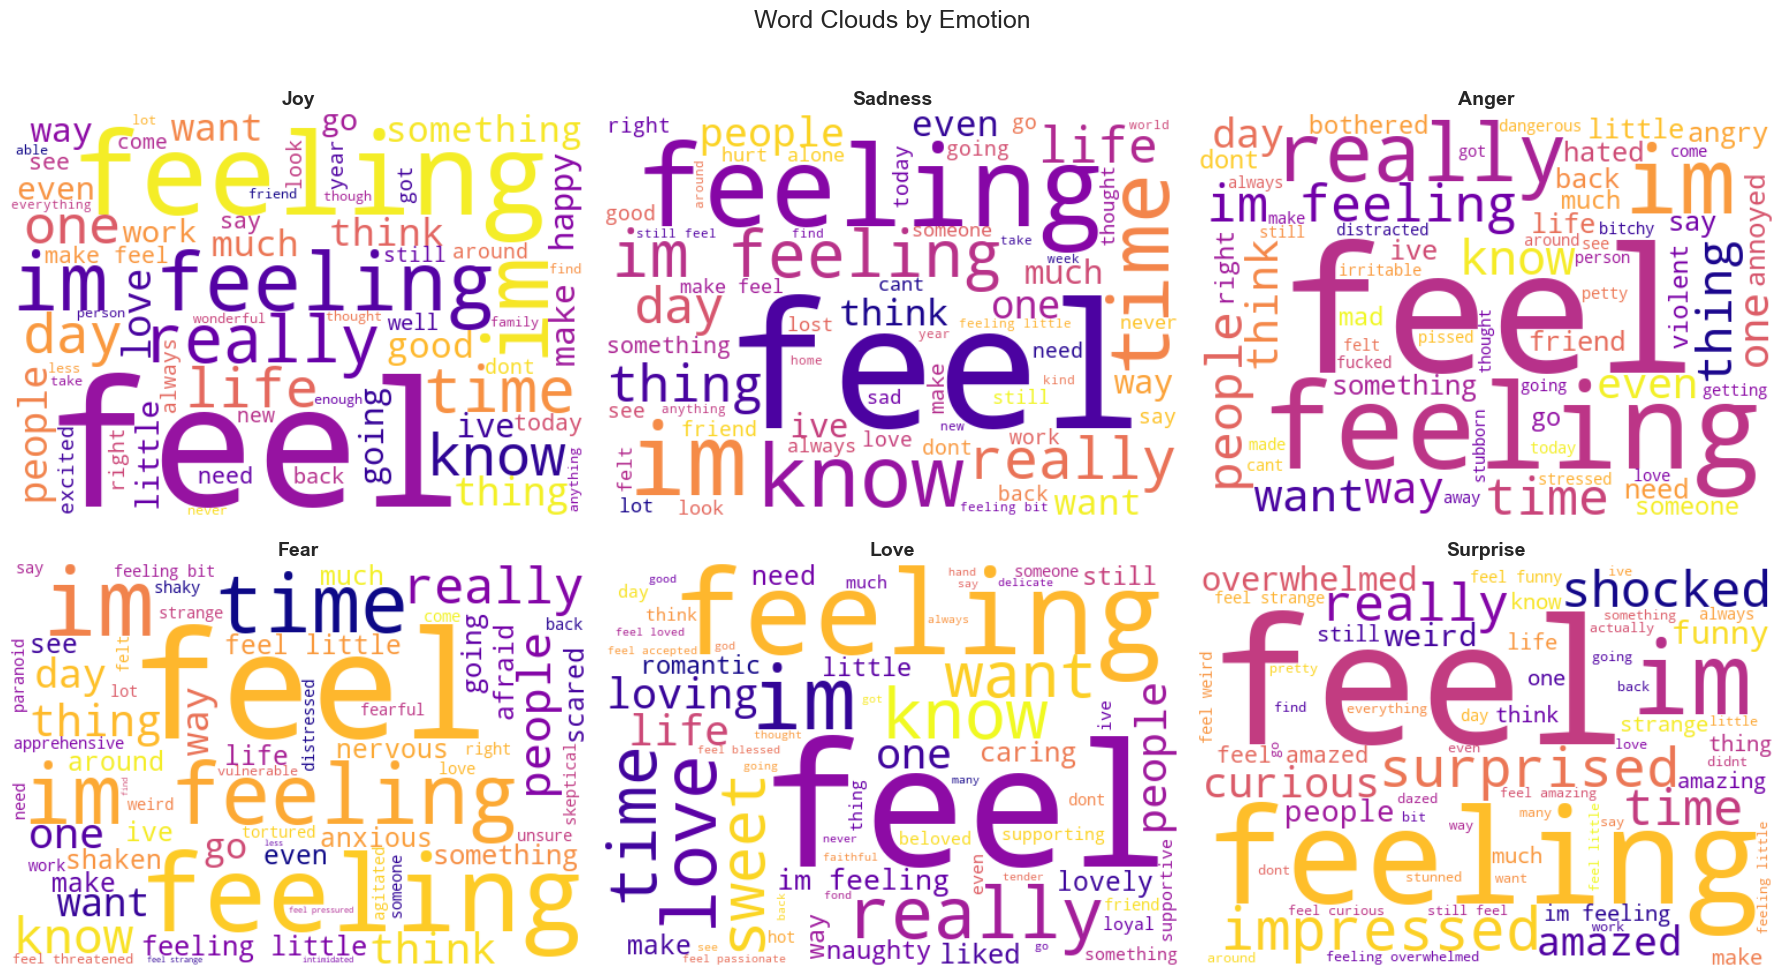

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
emotions_list = ['joy', 'sadness', 'anger', 'fear', 'love', 'surprise']

for i, emo in enumerate(emotions_list):
    emo_text = ' '.join(df[df['emotion'] == emo]['clean_text'].fillna('').tolist())
    if emo_text.strip():
        wc = WordCloud(width=500, height=350, background_color='white',
                      colormap='plasma', max_words=60).generate(emo_text)
        axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(emo.capitalize(), fontsize=14, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Word Clouds by Emotion', fontsize=18, y=1.01)
plt.tight_layout()
plt.savefig('visualizations/wordclouds_per_emotion.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.3 Confusion Matrices

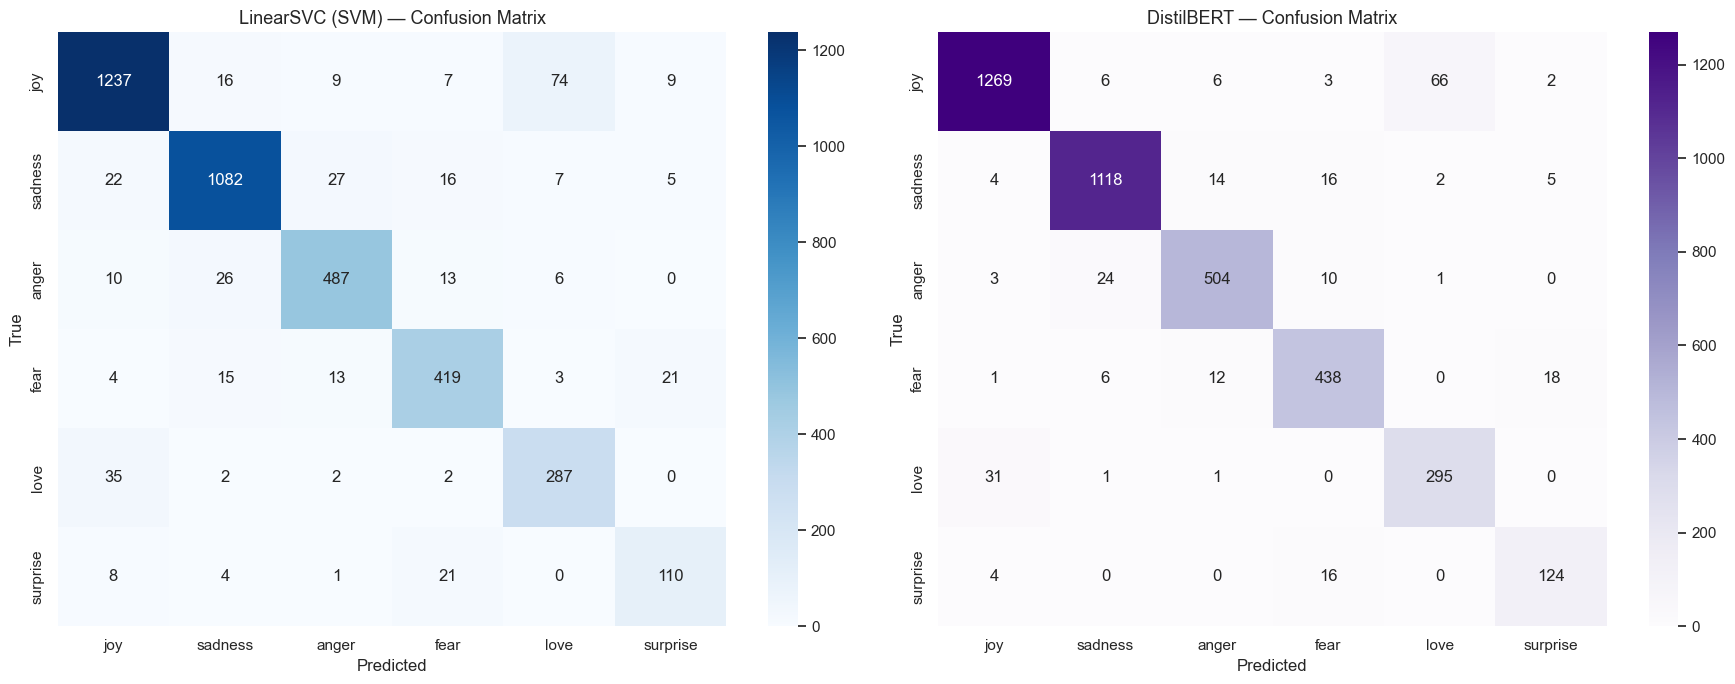

In [61]:
emotion_order = ['joy', 'sadness', 'anger', 'fear', 'love', 'surprise']
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# SVM confusion matrix
cm_svm = confusion_matrix(y_test, svm_preds, labels=emotion_order)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_order, yticklabels=emotion_order, ax=axes[0])
axes[0].set_title('LinearSVC (SVM) — Confusion Matrix', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# DistilBERT confusion matrix
cm_bert = confusion_matrix(y_test_bert, bert_preds, labels=emotion_order)
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Purples',
            xticklabels=emotion_order, yticklabels=emotion_order, ax=axes[1])
axes[1].set_title('DistilBERT — Confusion Matrix', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('visualizations/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 10: Save Best Models

In [62]:
# Save all models for Streamlit app
joblib.dump(svm_model,  'models/best_classical_model.pkl')
joblib.dump(tfidf,      'models/tfidf_vectorizer.pkl')
joblib.dump(lr_w2v,     'models/lr_word2vec_model.pkl')
w2v_model.save('models/word2vec.model')
# DistilBERT already saved in Section 7

print('All models saved:')
print('  models/best_classical_model.pkl  — LinearSVC (SVM) + TF-IDF')
print('  models/tfidf_vectorizer.pkl')
print('  models/lr_word2vec_model.pkl     — LR on Word2Vec')
print('  models/word2vec.model')
print('  models/best_transformer_model/   — DistilBERT')

All models saved:
  models/best_classical_model.pkl  — LinearSVC (SVM) + TF-IDF
  models/tfidf_vectorizer.pkl
  models/lr_word2vec_model.pkl     — LR on Word2Vec
  models/word2vec.model
  models/best_transformer_model/   — DistilBERT


## Summary & Analysis

### Expected Results

| Model | Feature | Accuracy | Macro-F1 | Notes |
|-------|---------|----------|----------|-------|
| Naive Bayes | TF-IDF | ~78% | ~70% | Fast baseline; struggles with minority classes |
| Logistic Regression | TF-IDF | ~85% | ~83% | Good balance of speed and accuracy |
| LinearSVC (SVM) | TF-IDF | ~87% | ~86% | Best classical model for text classification |
| Logistic Regression | Word2Vec | ~75% | ~73% | Demonstrates semantic embeddings |
| **DistilBERT** | Raw text | **~92%** | **~91%** | Best overall; captures context and nuance |

### Why DistilBERT Wins
1. **Contextual representations** — understands "I'm not happy" vs "I'm happy"
2. **Pre-trained on 3.3B words** — rich general language knowledge
3. **Fine-tuned on our domain** — adapts to social media emotion patterns

### Class Imbalance Discussion
Even with this more balanced dataset (~2.7x imbalance vs 14x in GoEmotions),
`fear` and `surprise` may still score lower than `joy`/`sadness` in per-class F1.
We address this with `class_weight='balanced'` in classical models.
Macro-F1 (average across all classes, equal weight) gives a fair overall picture.

### Rubric Coverage
| Requirement | Where Addressed |
|-------------|----------------|
| Data loading + EDA | Section 2 |
| Complete preprocessing | Section 3 |
| 2 feature methods (TF-IDF + Word2Vec) | Section 5 |
| ≥2 models compared | Section 6 |
| Transformer bonus (+5) | Section 7 |
| Evaluation (acc + F1 + confusion matrix) | Sections 6-9 |
| ≥5 visualizations | Sections 2, 5, 8, 9 |
| Models saved | Section 10 |
